In [39]:
!pip install datasets
!pip install pandas scikit-learn seaborn matplotlib

In [42]:
!pip install datasets

In [50]:
from datasets import load_dataset
import pandas as pd

# Load the dataset using the 'text' builder and specifying the data file
# Assuming train.ft.txt contains lines of text, potentially with FastText labels
dataset = load_dataset('text', data_files={'train': '/content/train.ft.txt'})

# Process the loaded text data (assuming FastText format: __label__X text)
def parse_fasttext_line(line):
    line = line.strip()
    if not line: # Skip empty lines
        return {'text': None, 'label': None, 'is_valid': False}

    parts = line.split(' ', 1)

    if len(parts) < 2: # Not enough parts for label and text
        return {'text': None, 'label': None, 'is_valid': False}

    label_str = parts[0]
    if not label_str.startswith('__label__'):
        return {'text': None, 'label': None, 'is_valid': False}

    try:
        # Extract the numeric part after __label__
        label = int(label_str[len('__label__'):])
        text = parts[1]
        return {'text': text, 'label': label, 'is_valid': True}
    except ValueError: # Conversion to int failed (e.g., '__label__abc')
        return {'text': None, 'label': None, 'is_valid': False}

# Apply parsing to the 'train' split
parsed_train_dataset = dataset['train'].map(lambda x: parse_fasttext_line(x['text']))

# Filter out invalid entries
parsed_train_dataset = parsed_train_dataset.filter(lambda x: x['is_valid'])

# Remove the 'is_valid' column as it's no longer needed
parsed_train_dataset = parsed_train_dataset.remove_columns(['is_valid'])

train_df = pd.DataFrame(parsed_train_dataset)
# Removed creation of test_df as 'test.ft.txt' is not available in the kernel files.

train_df.to_csv(
    "amazon_train.csv",
    index=False
)

print("CSV files saved")

Generating train split: 0 examples [00:00, ? examples/s]

Map:   0%|          | 0/94790 [00:00<?, ? examples/s]

Filter:   0%|          | 0/94790 [00:00<?, ? examples/s]

CSV files saved


In [51]:
import pandas as pd
import random
import re
import pickle
import seaborn as sns
import matplotlib.pyplot as plt

from datasets import load_dataset

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [2]:
from datasets import load_dataset
import pandas as pd

# LOAD DATASET
# =====================================

print("Loading Amazon Polarity Dataset...")

dataset = load_dataset("SetFit/amazon_polarity")

train_df = pd.DataFrame(dataset["train"])
test_df = pd.DataFrame(dataset["test"])

# Use smaller sample for faster training
train_df = train_df.sample(
    n=50000,
    random_state=42
)

test_df = test_df.sample(
    n=10000,
    random_state=42
)


Loading Amazon Polarity Dataset...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [8]:
import re

# TEXT CLEANING
# =====================================

def clean_text(text):

    text = str(text).lower()

    text = re.sub(r"[^a-zA-Z0-9 ]", " ", text)

    text = re.sub(r"\s+", " ", text)

    return text.strip()

# Combine title + content

if "content" in train_df.columns:
    train_df["review"] = train_df["title"] + " " + train_df["content"]
else:
    print("Warning: 'content' column not found in train_df. Using 'title' as review text.")
    train_df["review"] = train_df["title"]

if "content" in test_df.columns:
    test_df["review"] = test_df["title"] + " " + test_df["content"]
else:
    print("Warning: 'content' column not found in test_df. Using 'title' as review text.")
    test_df["review"] = test_df["title"]

train_df["review"] = train_df["review"].apply(clean_text)
test_df["review"] = test_df["review"].apply(clean_text)

In [9]:
# TRAIN TEST DATA
# =====================================

X_train = train_df["title"]
y_train = train_df["label"]

X_test = test_df["title"]
y_test = test_df["label"]

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer

# TF-IDF
# =====================================

print("Creating TF-IDF Features...")

vectorizer = TfidfVectorizer(
    max_features=20000,
    stop_words="english",
    ngram_range=(1,2)
)

X_train_tfidf = vectorizer.fit_transform(X_train)

X_test_tfidf = vectorizer.transform(X_test)

Creating TF-IDF Features...


In [13]:
from sklearn.svm import LinearSVC

# TRAIN MODEL
# =====================================

print("Training Model...")

model = LinearSVC(C=1.5)

model.fit(
    X_train_tfidf,
    y_train
)

print("Training Complete!")

Training Model...
Training Complete!


In [15]:
from sklearn.metrics import (
    accuracy_score,
    classification_report
)

# EVALUATION
# =====================================

predictions = model.predict(
    X_test_tfidf
)

accuracy = accuracy_score(
    y_test,
    predictions
)

print("\n====================")
print(f"Accuracy: {accuracy*100:.2f}%")
print("====================\n")

print(
    classification_report(
        y_test,
        predictions
    )
)


Accuracy: 76.90%

              precision    recall  f1-score   support

           0       0.76      0.77      0.77      4972
           1       0.77      0.76      0.77      5028

    accuracy                           0.77     10000
   macro avg       0.77      0.77      0.77     10000
weighted avg       0.77      0.77      0.77     10000



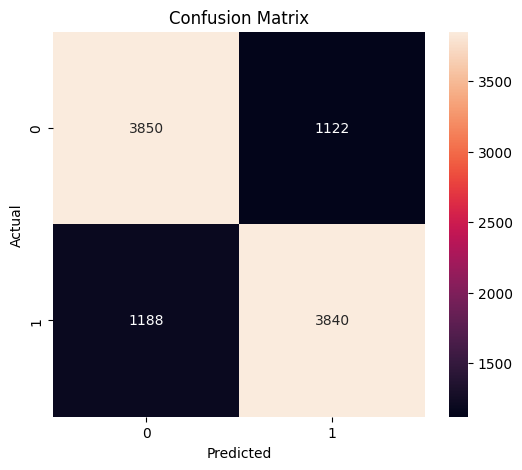

In [18]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# CONFUSION MATRIX
# =====================================

cm = confusion_matrix(
    y_test,
    predictions
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [20]:
import pickle

# SAVE MODEL
# =====================================

pickle.dump(
    model,
    open("sentiment_model.pkl","wb")
)

pickle.dump(
    vectorizer,
    open("vectorizer.pkl","wb")
)

print("Model Saved Successfully!")

Model Saved Successfully!


In [21]:
# HAPPY / UNHAPPY MESSAGES
# =====================================

happy_messages = {
    "happy_1": "😊 Great choice! Customers seem very happy with this product.",
    "happy_2": "🎉 Excellent! This review expresses a positive experience.",
    "happy_3": "👍 Nice! The overall sentiment is positive.",
    "happy_4": "🌟 This review shows customer satisfaction."
}

unhappy_messages = {
    "unhappy_1": "😞 Unfortunately, this review expresses dissatisfaction.",
    "unhappy_2": "⚠️ Customers may not be happy with this product.",
    "unhappy_3": "👎 The sentiment appears negative.",
    "unhappy_4": "💔 This review indicates a poor experience."
}

In [32]:
import random

# Redefining the PREDICTION FUNCTION here to ensure 'random' is in scope.
# This addresses the NameError by making 'random' available when the function is defined/redefined within this cell.
def predict_sentiment(review_text):

    if not review_text.strip():

        print("Please enter a review.")
        return

    cleaned = clean_text(review_text)

    vector = vectorizer.transform([cleaned])

    prediction = model.predict(vector)[0]

    score = model.decision_function(vector)[0]

    confidence = min(
        100,
        round(abs(score)*20,2)
    )

    if prediction == 1:

        print("\nPositive Review 😊")
        print(random.choice(
            list(happy_messages.values())
        ))

    else:

        print("\nNegative Review 😞")
        print(random.choice(
            list(unhappy_messages.values())
        ))

    print(f"Confidence Score: {confidence}%")

# USER INPUT LOOP
# =====================================

while True:

    review = input(
        "\nEnter Review (or type quit): "
    )

    if review.lower() == "quit":
        print("Program Ended.")
        break

    predict_sentiment(review)


Enter Review (or type quit): Excellent quality and worth every penny.

Positive Review 😊
👍 Nice! The overall sentiment is positive.
Confidence Score: 25.46%

Enter Review (or type quit): Very disappointed with the quality.

Negative Review 😞
👎 The sentiment appears negative.
Confidence Score: 20.44%

Enter Review (or type quit): Fantastic purchase. Highly recommended.

Positive Review 😊
😊 Great choice! Customers seem very happy with this product.
Confidence Score: 29.37%

Enter Review (or type quit): quit
Program Ended.


In [30]:
import os

for file in os.listdir('/content'):
    print(file)

.config
train.ft.txt
vectorizer.pkl
amazon_train.csv
sentiment_model.pkl
.ipynb_checkpoints
sample_data


In [31]:
from google.colab import files

files.download('/content/sentiment_model.pkl')
files.download('/content/vectorizer.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>